# Facial Expression Recognition with CNNs - FER-2013

## Project Goal

The goal of this project is to build a deep learning model that can classify facial expressions from 48x48 grayscale face images.

The model will learn to classify seven emotion classes:

- angry
- disgust
- fear
- happy
- neutral
- sad
- surprise

This notebook works both as code and as a project report. The project follows an iterative machine learning workflow:

1. Explore and understand the dataset
2. Prepare image data for neural networks
3. Build a baseline CNN model
4. Improve the model using regularization and data augmentation
5. Compare different model versions
6. Evaluate the final model on unseen test data
7. Use the model to predict emotions from new images
8. Reflect on the result, limitations and possible improvements

In [1]:
from pathlib import Path
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
# Project paths
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "FER-2013"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

MODEL_DIR = PROJECT_ROOT / "models"
IMAGE_DIR = PROJECT_ROOT / "images"

MODEL_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)
print("Train directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        "Dataset folders were not found. Expected structure: "
        "data/FER-2013/train and data/FER-2013/test"
    )

Project root: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013
Dataset directory: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\data\FER-2013
Train directory: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\data\FER-2013\train
Test directory: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\data\FER-2013\test
Train directory exists: True
Test directory exists: True


## 1. Understanding the Dataset

Before building the model, I first inspect the dataset. This is important because the number of images per class can affect how well the model learns each emotion.

If one class has many more images than another class, the model can become biased toward the larger classes.

In [4]:
def count_images_per_class(directory):
    class_counts = {}

    for class_folder in sorted(directory.iterdir()):
        if class_folder.is_dir():
            image_files = list(class_folder.glob("*"))
            class_counts[class_folder.name] = len(image_files)

    return class_counts


train_counts = count_images_per_class(TRAIN_DIR)
test_counts = count_images_per_class(TEST_DIR)

class_names = sorted(train_counts.keys())

df_counts = pd.DataFrame({
    "class": class_names,
    "train_count": [train_counts[class_name] for class_name in class_names],
    "test_count": [test_counts[class_name] for class_name in class_names],
})

df_counts["total_count"] = df_counts["train_count"] + df_counts["test_count"]

df_counts

,class,train_count,test_count,total_count
0,angry,3995,958,4953
1,disgust,436,111,547
2,fear,4097,1024,5121
3,happy,7215,1774,8989
4,neutral,4965,1233,6198
5,sad,4830,1247,6077
6,surprise,3171,831,4002


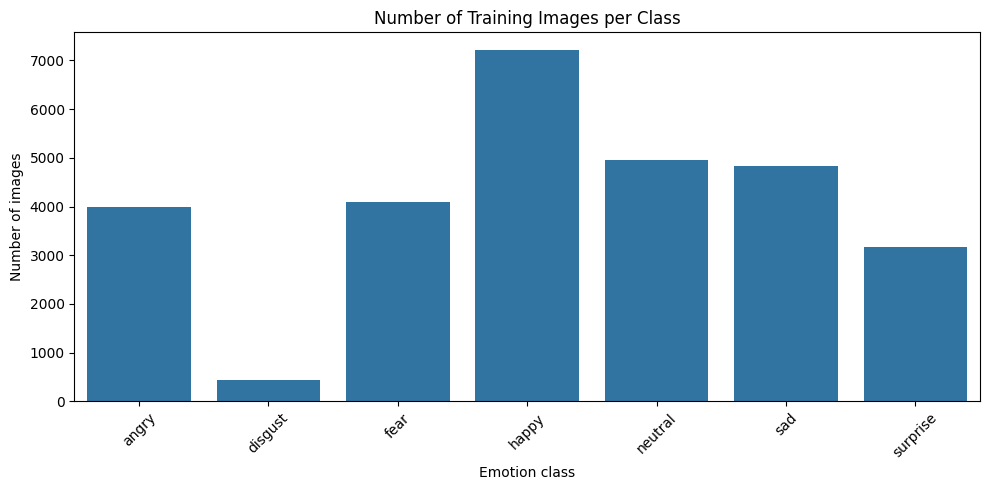

In [5]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_counts, x="class", y="train_count")
plt.title("Number of Training Images per Class")
plt.xlabel("Emotion class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(IMAGE_DIR / "class_distribution.png", dpi=300)
plt.show()

### Dataset Balance

The dataset is not perfectly balanced. Some classes have many more images than others. This can affect the model because a neural network usually learns better from classes that have more examples.

For example, if the class `disgust` has far fewer images than `happy`, the model may become better at recognizing happy faces than disgusted faces.

This is important to remember later when interpreting the classification report and confusion matrix.

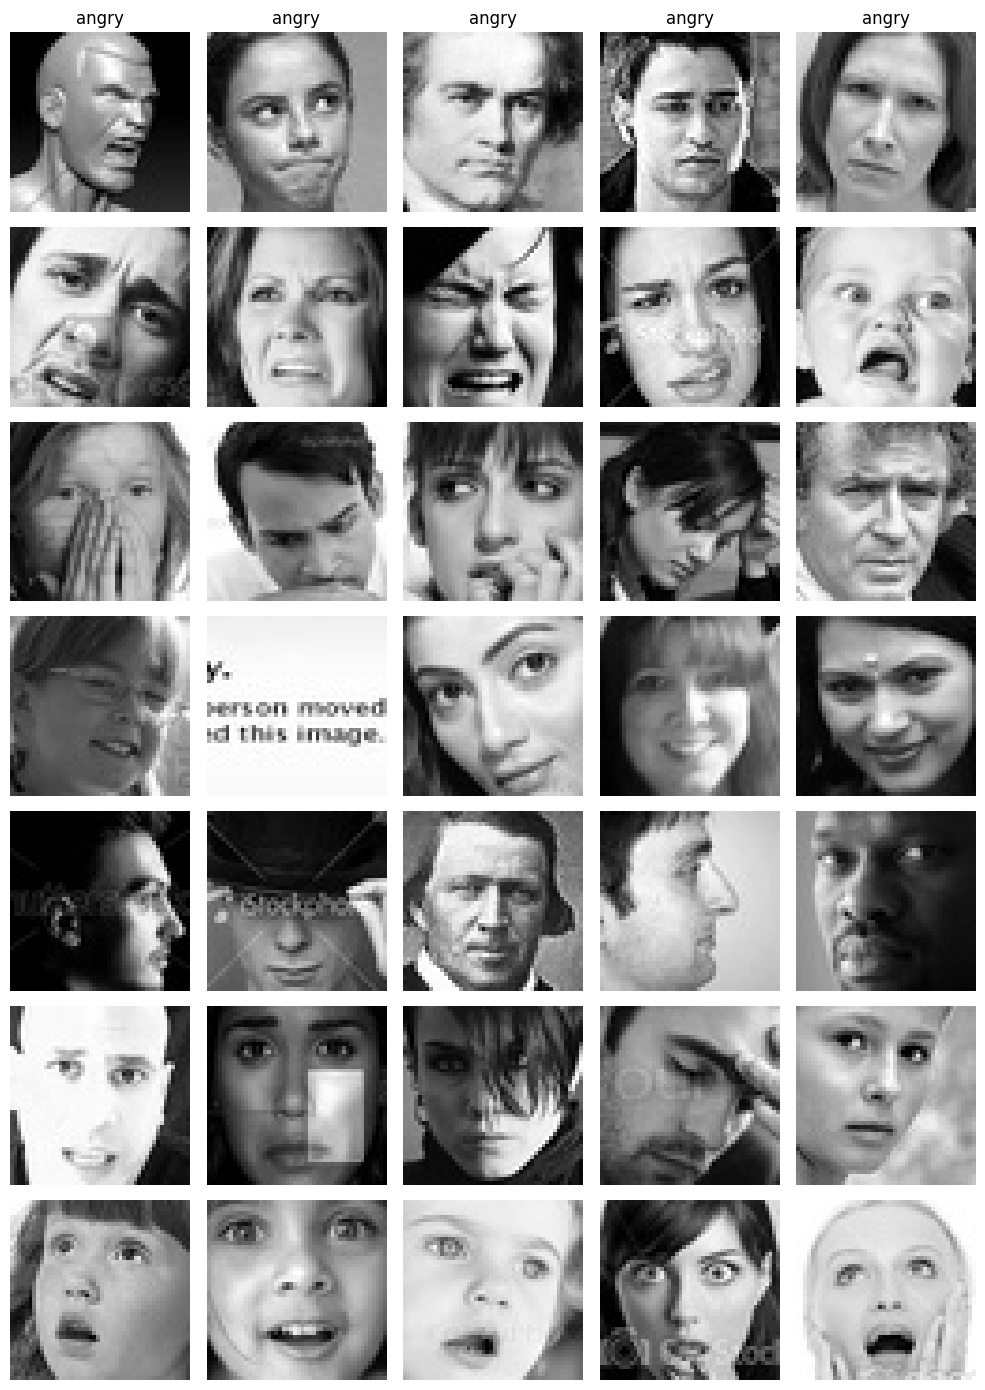

In [6]:
from PIL import Image

def show_sample_images(directory, class_names, samples_per_class=5):
    plt.figure(figsize=(samples_per_class * 2, len(class_names) * 2))

    plot_index = 1

    for class_name in class_names:
        class_dir = directory / class_name
        image_paths = list(class_dir.glob("*"))

        selected_images = random.sample(image_paths, min(samples_per_class, len(image_paths)))

        for image_path in selected_images:
            image = Image.open(image_path)

            plt.subplot(len(class_names), samples_per_class, plot_index)
            plt.imshow(image, cmap="gray")
            plt.axis("off")

            if plot_index <= samples_per_class:
                plt.title(class_name)

            plot_index += 1

    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "sample_images.png", dpi=300)
    plt.show()


show_sample_images(TRAIN_DIR, class_names, samples_per_class=5)

## 2. Data Preparation

The dataset is already divided into training and test folders. Each emotion class has its own folder.

For this project, I load the images using TensorFlow's `image_dataset_from_directory`.

The images are:

- loaded as grayscale images
- resized to 48x48 pixels
- grouped into batches
- normalized from pixel values 0-255 to values between 0 and 1

A validation split is also created from the training data. The validation data is used during training to check how well the model performs on unseen data while it is learning.

In [7]:
# Image and training settings
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2

print("Image size:", IMG_HEIGHT, "x", IMG_WIDTH)
print("Batch size:", BATCH_SIZE)
print("Validation split:", VALIDATION_SPLIT)

Image size: 48 x 48
Batch size: 64
Validation split: 0.2


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical"
)

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.


In [9]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode="categorical",
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [10]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 7


In [11]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda images, labels: (normalization_layer(images), labels))
val_ds = val_ds.map(lambda images, labels: (normalization_layer(images), labels))
test_ds = test_ds.map(lambda images, labels: (normalization_layer(images), labels))

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared successfully.")

Datasets prepared successfully.


In [13]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image batch shape: (64, 48, 48, 1)
Label batch shape: (64, 7)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Data Preparation Explanation

The loaded image batch has the shape `(64, 48, 48, 1)`.

This means:

- `64` images are processed at the same time in one batch
- each image has size `48x48`
- `1` means the image is grayscale

The labels have the shape `(64, 7)` because there are seven emotion classes. The labels are one-hot encoded, which means each image label is represented as a vector with seven values.

The pixel values were normalized to the range 0 to 1. This helps the neural network train more efficiently because the input values become smaller and more consistent.

## 3. Baseline CNN Model

The first model is a simple baseline CNN.

A baseline model is important because it gives a starting point. Later, I can compare improved models against this baseline and evaluate whether changes such as dropout, batch normalization and data augmentation actually improve the result.

This model uses:

- convolutional layers to detect image patterns
- max pooling layers to reduce image size and keep important features
- dense layers for classification
- softmax output because this is a multi-class classification problem

In [14]:
def build_baseline_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


baseline_model = build_baseline_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 1),
    num_classes=num_classes
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Baseline Model Explanation

The baseline model uses three convolutional blocks.

Each convolutional layer learns visual patterns from the images. In early layers, the model can learn simple patterns such as edges and shadows. In deeper layers, it can learn more complex facial features such as mouth shape, eye area and expression-related patterns.

Max pooling reduces the size of the feature maps. This makes the model faster and helps it focus on the most important features.

The final layer uses `softmax` because the model must choose between seven emotion classes.

In [15]:
baseline_checkpoint_path = MODEL_DIR / "baseline_model.keras"

baseline_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=baseline_checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

baseline_history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=baseline_callbacks
)

Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.3188 - loss: 1.7005 - val_accuracy: 0.4137 - val_loss: 1.5327
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4492 - loss: 1.4438 - val_accuracy: 0.4750 - val_loss: 1.3703
Epoch 3/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5013 - loss: 1.3100 - val_accuracy: 0.5001 - val_loss: 1.3264
Epoch 4/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5372 - loss: 1.2230 - val_accuracy: 0.5262 - val_loss: 1.2540
Epoch 5/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5620 - loss: 1.1595 - val_accuracy: 0.5172 - val_loss: 1.2581
Epoch 6/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5862 - loss: 1.1022 - val_accuracy: 0.5358 - val_loss: 1.2248
Epoch 7/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6096 - loss: 1.0418 - val_accuracy: 0.5311 - val_loss: 1.2225
Epoch 8/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.6334 - loss: 0.9870 - val_acc

In [16]:
def plot_training_curves(history, title, save_path=None):
    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

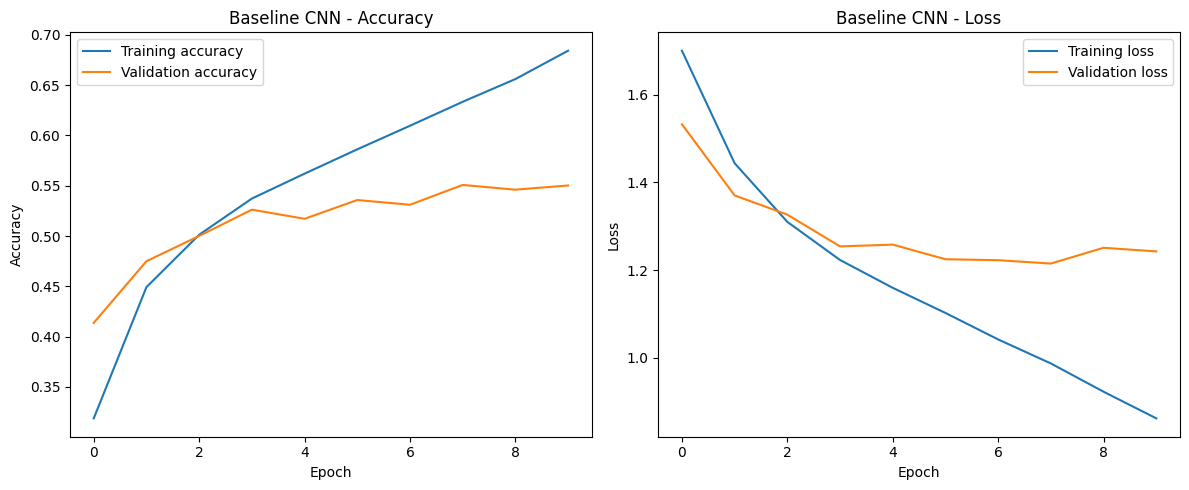

In [17]:
plot_training_curves(
    baseline_history,
    title="Baseline CNN",
    save_path=IMAGE_DIR / "training_curves_baseline.png"
)

In [18]:
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(test_ds)

print(f"Baseline test loss: {baseline_test_loss:.4f}")
print(f"Baseline test accuracy: {baseline_test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.5527 - loss: 1.2090
Baseline test loss: 1.2090
Baseline test accuracy: 0.5527


In [19]:
model_results = []

model_results.append({
    "model": "Baseline CNN",
    "test_loss": baseline_test_loss,
    "test_accuracy": baseline_test_accuracy
})

pd.DataFrame(model_results)

,model,test_loss,test_accuracy
0,Baseline CNN,1.208981,0.552661


### Baseline Model Result

The baseline CNN was able to learn patterns from the facial expression images.

The test accuracy was approximately **55.27%**.

This means that the baseline CNN correctly classified a little more than half of the unseen test images. This is a reasonable starting point for the FER-2013 dataset, which is challenging because the images are small, grayscale and sometimes visually ambiguous.

This gives a first reference point for the project. However, the baseline model is still quite simple. It does not use dropout, batch normalization or data augmentation. Because of that, it may overfit the training data or fail to generalize well to unseen images.

In the next step, I will build an improved CNN model and compare it with this baseline.

## 4. Improved CNN Model

The baseline model gives a useful starting point, but it is still quite simple.

In this improved model, I add techniques that are commonly used to improve generalization:

- **Data augmentation**: creates small variations of training images, such as slight rotation and zoom. This helps the model become less sensitive to small changes in face position.
- **Batch normalization**: stabilizes training and can help the model learn more efficiently.
- **Dropout**: randomly disables some neurons during training, which helps reduce overfitting.
- **More convolutional layers**: gives the model more capacity to learn complex facial expression patterns.

This model is compared with the baseline CNN to evaluate whether the changes improve performance.

In [20]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    layers.RandomTranslation(0.08, 0.08)
], name="data_augmentation")

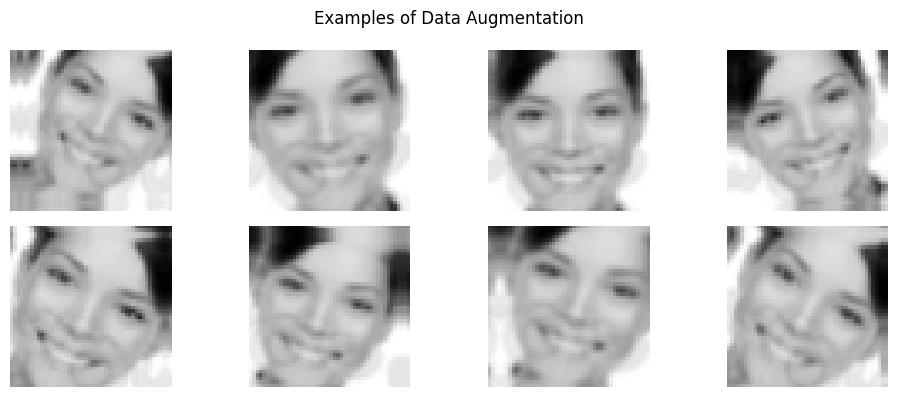

In [21]:
for images, labels in train_ds.take(1):
    sample_image = images[0]
    break

plt.figure(figsize=(10, 4))

for i in range(8):
    augmented_image = data_augmentation(tf.expand_dims(sample_image, 0), training=True)

    plt.subplot(2, 4, i + 1)
    plt.imshow(tf.squeeze(augmented_image), cmap="gray")
    plt.axis("off")

plt.suptitle("Examples of Data Augmentation")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "data_augmentation_examples.png", dpi=300)
plt.show()

### Data Augmentation Explanation

Data augmentation is used only during training. It creates slightly modified versions of the original images.

This can help the model generalize better because real face images can vary in position, angle and size. Instead of memorizing the exact training images, the model learns more flexible facial expression patterns.

This is useful for FER-2013 because the images are small, grayscale and can be noisy.

In [22]:
def build_improved_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        data_augmentation,

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),

        layers.Flatten(),

        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.50),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


improved_model = build_improved_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 1),
    num_classes=num_classes
)

improved_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,177,319 (4.49 MB)

 Trainable params: 1,175,399 (4.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

### Improved Model Explanation

The improved model has more convolutional layers than the baseline model. This gives the model more ability to learn complex image patterns.

Batch normalization is added after convolutional layers to make training more stable. Dropout is added after pooling layers and dense layers to reduce overfitting.

Compared with the baseline model, this model is more advanced and includes regularization. The goal is not only to get higher training accuracy, but to improve performance on validation and test data.

In [23]:
improved_checkpoint_path = MODEL_DIR / "improved_model.keras"

improved_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath=improved_checkpoint_path,
        monitor="val_loss",
        save_best_only=True
    )
]

improved_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=improved_callbacks
)

Epoch 1/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 41s 105ms/step - accuracy: 0.2192 - loss: 2.2060 - val_accuracy: 0.1855 - val_loss: 2.1398
Epoch 2/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.2875 - loss: 1.8107 - val_accuracy: 0.3330 - val_loss: 1.6730
Epoch 3/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.3419 - loss: 1.6704 - val_accuracy: 0.2860 - val_loss: 2.0054
Epoch 4/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.3894 - loss: 1.5662 - val_accuracy: 0.4607 - val_loss: 1.4041
Epoch 5/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.4298 - loss: 1.4734 - val_accuracy: 0.4545 - val_loss: 1.4237
Epoch 6/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.4575 - loss: 1.4095 - val_accuracy: 0.4599 - val_loss: 1.3865
Epoch 7/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 43s 120ms/step - accuracy: 0.4787 - loss: 1.3654 - val_accuracy: 0.5057 - val_loss: 1.2872
Epoch 8/25
359/359 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.4954 - loss: 1

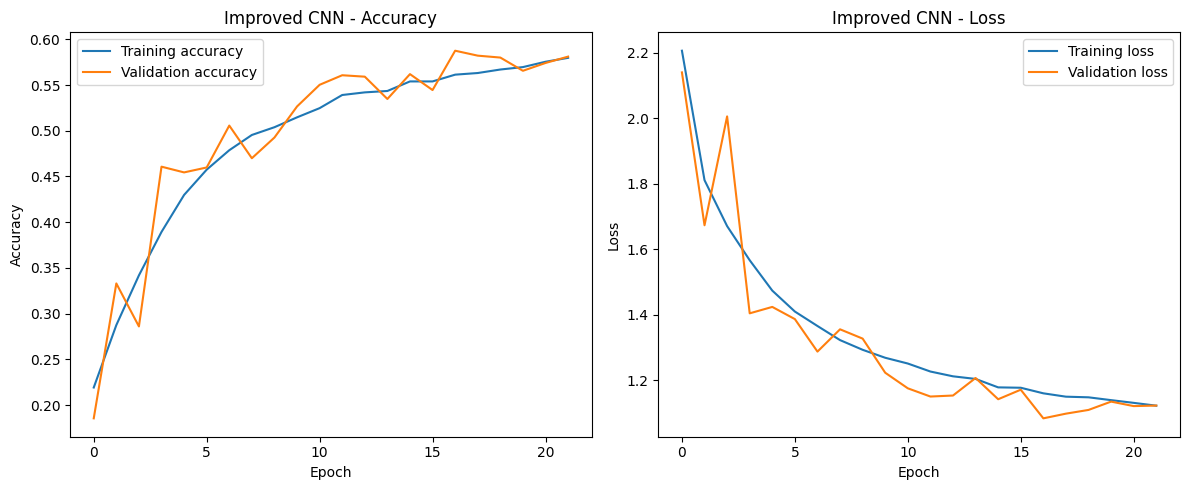

In [24]:
plot_training_curves(
    improved_history,
    title="Improved CNN",
    save_path=IMAGE_DIR / "training_curves_improved.png"
)

In [25]:
improved_test_loss, improved_test_accuracy = improved_model.evaluate(test_ds)

print(f"Improved test loss: {improved_test_loss:.4f}")
print(f"Improved test accuracy: {improved_test_accuracy:.4f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5840 - loss: 1.0819
Improved test loss: 1.0819
Improved test accuracy: 0.5840


In [26]:
model_results.append({
    "model": "Improved CNN",
    "test_loss": improved_test_loss,
    "test_accuracy": improved_test_accuracy
})

results_df = pd.DataFrame(model_results)
results_df

,model,test_loss,test_accuracy
0,Baseline CNN,1.208981,0.552661
1,Improved CNN,1.081937,0.584007


In [27]:
final_model_path = MODEL_DIR / "best_model.keras"
improved_model.save(final_model_path)

print("Final model saved to:", final_model_path)

Final model saved to: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\models\best_model.keras


### Improved Model Result

The improved CNN achieved a test accuracy of approximately **58.40%**.

This is an improvement compared with the baseline CNN, which achieved approximately 55.27% test accuracy. The improved model also had a lower test loss, decreasing from 1.2090 to 1.0819.

This suggests that the added techniques, such as data augmentation, batch normalization, dropout and a deeper CNN architecture, helped the model generalize better to unseen test images.

Compared with the baseline model, the improved model used more convolutional layers, batch normalization, dropout and data augmentation.

The goal of these changes was to improve generalization and reduce overfitting. By comparing the baseline and improved model, I can evaluate whether the additional techniques improved performance on unseen test data.

## 5. Model Evaluation

Accuracy gives a general idea of how well the model performs, but it does not show which emotion classes are easy or difficult for the model.

To understand the model more deeply, I evaluate it using:

- a classification report
- a confusion matrix
- per-class precision, recall and F1-score

This helps identify if the model performs worse on specific classes, especially classes with fewer training examples.

In [28]:
# Collect true labels and predicted labels from the test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = improved_model.predict(images, verbose=0)

    true_classes = np.argmax(labels.numpy(), axis=1)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(true_classes)
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Number of true labels:", len(y_true))
print("Number of predicted labels:", len(y_pred))

Number of true labels: 7178
Number of predicted labels: 7178


In [29]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
angry,0.511737,0.455115,0.481768,958.000000
disgust,0.714286,0.045045,0.084746,111.000000
fear,0.483122,0.223633,0.305741,1024.000000
happy,0.774242,0.864149,0.816729,1774.000000
neutral,0.477991,0.686942,0.563727,1233.000000
sad,0.438571,0.492382,0.463921,1247.000000
surprise,0.761905,0.635379,0.692913,831.000000
accuracy,0.584007,0.584007,0.584007,0.584007
macro avg,0.594551,0.486092,0.487078,7178.000000
weighted avg,0.586118,0.584007,0.568723,7178.000000


In [30]:
report_df.to_csv(IMAGE_DIR / "classification_report.csv")

print("Classification report saved to:", IMAGE_DIR / "classification_report.csv")

Classification report saved to: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\images\classification_report.csv


### Classification Report Explanation

The classification report gives more detailed information than accuracy alone.

- **Precision** shows how reliable the model is when it predicts a specific emotion.
- **Recall** shows how many real examples of an emotion the model successfully detects.
- **F1-score** combines precision and recall into one balanced metric.
- **Support** shows how many test images exist for each class.

This is important because the dataset is imbalanced. A model can achieve acceptable overall accuracy while still performing poorly on smaller or more difficult classes.

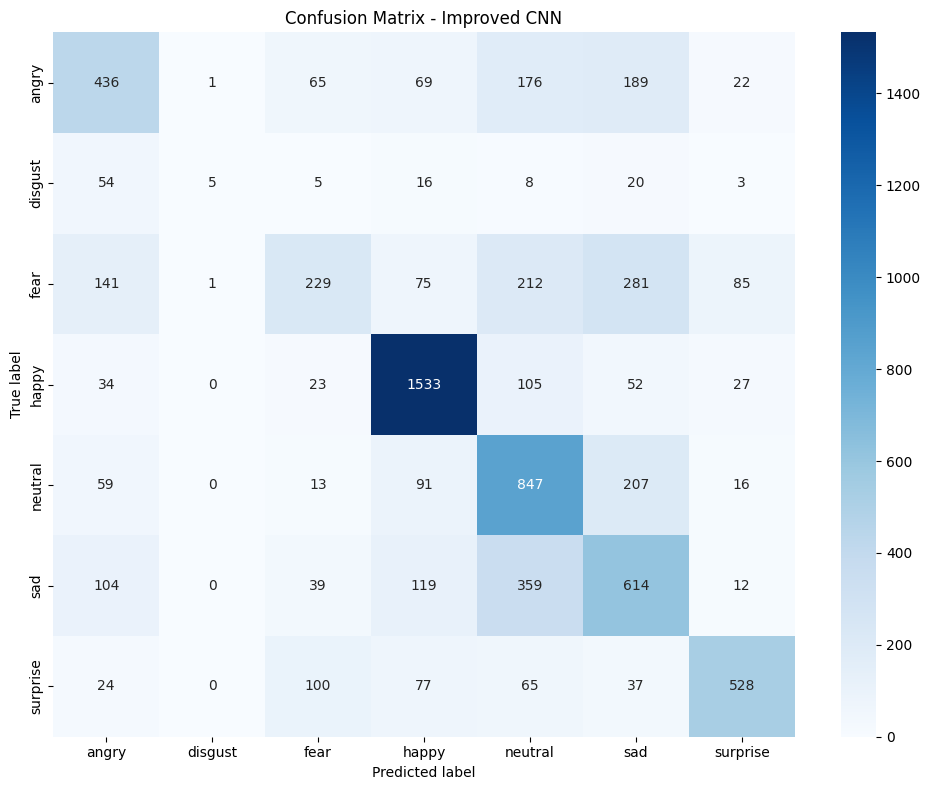

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Improved CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300)
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows where the model makes correct and incorrect predictions.

The diagonal values show correct predictions. Values outside the diagonal show mistakes.

For example, if many `sad` images are predicted as `neutral`, this means the model has difficulty separating those two emotions.

This type of evaluation is important because facial expressions can be visually similar, especially in small 48x48 grayscale images.

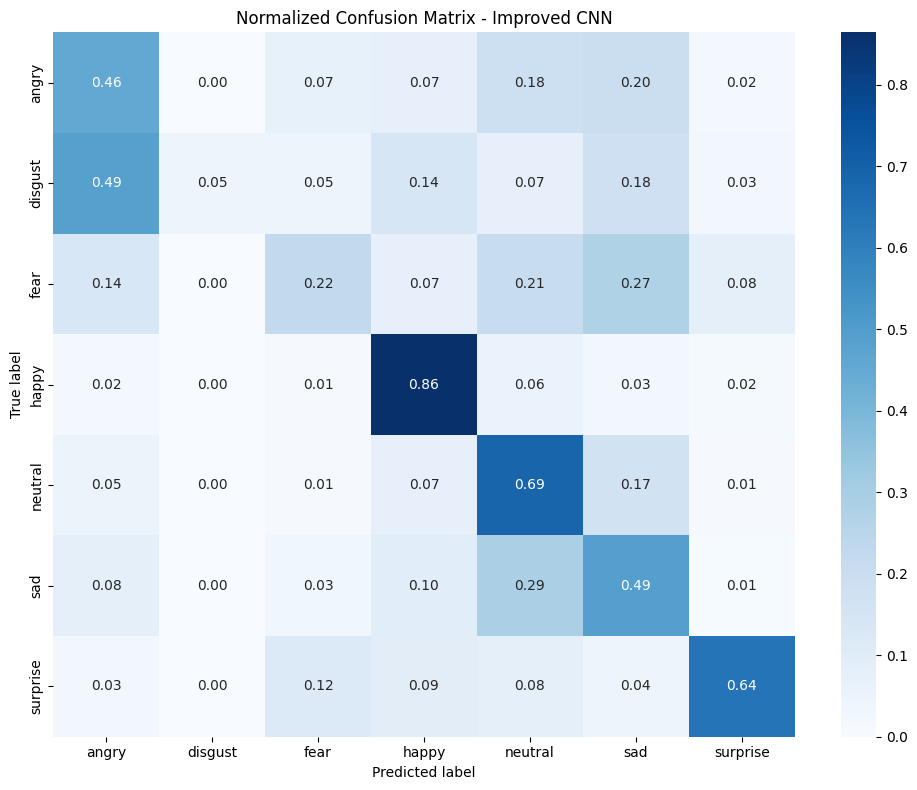

In [32]:
cm_normalized = confusion_matrix(y_true, y_pred, normalize="true")

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix - Improved CNN")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()

plt.savefig(IMAGE_DIR / "confusion_matrix_normalized.png", dpi=300)
plt.show()

In [33]:
results_df = pd.DataFrame(model_results)
results_df["test_accuracy_percent"] = results_df["test_accuracy"] * 100
results_df["test_loss"] = results_df["test_loss"].round(4)
results_df["test_accuracy"] = results_df["test_accuracy"].round(4)
results_df["test_accuracy_percent"] = results_df["test_accuracy_percent"].round(2)

results_df

,model,test_loss,test_accuracy,test_accuracy_percent
0,Baseline CNN,1.2090,0.5527,55.27
1,Improved CNN,1.0819,0.5840,58.40


### Model Comparison

The baseline CNN and improved CNN were compared using test accuracy and test loss.

The baseline model achieved a test accuracy of approximately **55.27%** and a test loss of **1.2090**.

The improved model achieved a test accuracy of approximately **58.40%** and a test loss of **1.0819**.

The improved model performed better than the baseline model. The test accuracy increased by approximately **3.13 percentage points**, and the test loss decreased.

The improved model includes data augmentation, batch normalization and dropout. These changes were added to improve generalization and reduce overfitting.

The improvement shows that the added techniques helped the model learn more robust facial expression patterns. However, the improvement is still moderate, which shows that model architecture alone is not the only factor. Dataset quality, class imbalance, small image resolution and similarity between facial expressions also affect the result.

In [34]:
class_report_df = report_df.loc[class_names, ["precision", "recall", "f1-score", "support"]].copy()
class_report_df = class_report_df.sort_values("f1-score", ascending=False)

class_report_df

,precision,recall,f1-score,support
happy,0.774242,0.864149,0.816729,1774.0
surprise,0.761905,0.635379,0.692913,831.0
neutral,0.477991,0.686942,0.563727,1233.0
angry,0.511737,0.455115,0.481768,958.0
sad,0.438571,0.492382,0.463921,1247.0
fear,0.483122,0.223633,0.305741,1024.0
disgust,0.714286,0.045045,0.084746,111.0


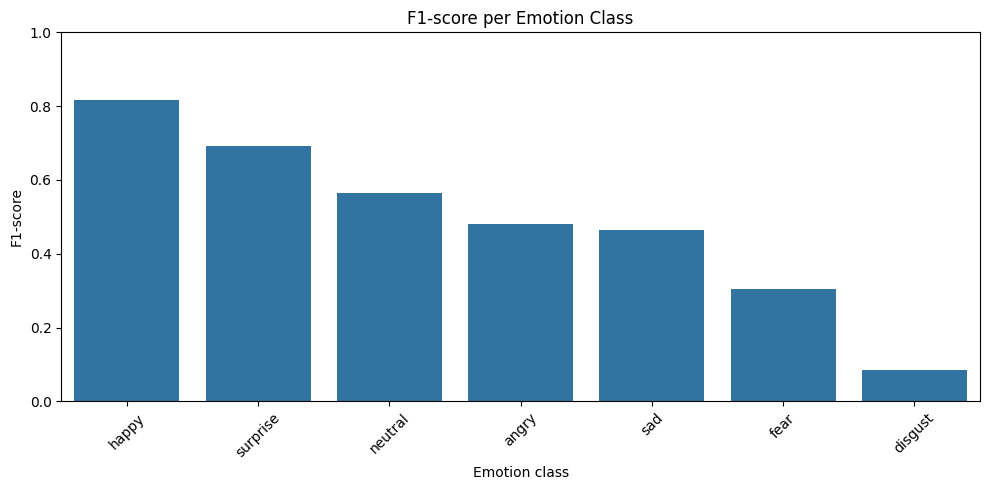

In [35]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=class_report_df.reset_index(),
    x="index",
    y="f1-score"
)

plt.title("F1-score per Emotion Class")
plt.xlabel("Emotion class")
plt.ylabel("F1-score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(IMAGE_DIR / "f1_score_per_class.png", dpi=300)
plt.show()

### Per-Class Performance Analysis

The model does not perform equally well on all emotion classes.

The strongest classes are **happy**, **surprise** and **neutral**, based on their F1-scores.

The weakest classes are **disgust**, **fear** and **sad**.

The `happy` class performs best, with an F1-score of approximately **0.82**. This is likely because happy expressions are visually clearer and because the dataset contains many happy images.

The `disgust` class performs worst, with an F1-score of approximately **0.08** and recall of only **0.05**. This means that the model almost never detects real disgust images. One likely reason is class imbalance, because the disgust class has far fewer training examples than the other classes.

The `fear` class is also difficult for the model, with an F1-score of approximately **0.31**. This may be because fear can look similar to surprise or sad expressions in small grayscale images.

The model performs reasonably well on `neutral`, but the precision is lower than the recall. This suggests that the model sometimes predicts neutral too often when it is uncertain.

This shows that overall accuracy is not enough to fully understand the model. Per-class metrics are necessary for a deeper evaluation.

## 6. Prediction on New Images

After training and evaluating the model, I use it to make predictions on individual unseen images.

The prediction image must be prepared in the same way as the training images:

- loaded as grayscale
- resized to 48x48 pixels
- converted to an array
- normalized to values between 0 and 1
- reshaped into batch format

This step shows how the trained model can be used as a small program, not only as a training experiment.

In [36]:
def predict_emotion(image_path, model, class_names):
    """
    Loads an image, preprocesses it, predicts the emotion class,
    and returns the predicted class and confidence.
    """

    # Load image as grayscale and resize to 48x48
    image = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(IMG_HEIGHT, IMG_WIDTH)
    )

    # Convert image to array
    image_array = tf.keras.utils.img_to_array(image)

    # Normalize pixel values from 0-255 to 0-1
    image_array = image_array / 255.0

    # Add batch dimension: (48, 48, 1) -> (1, 48, 48, 1)
    image_batch = np.expand_dims(image_array, axis=0)

    # Make prediction
    predictions = model.predict(image_batch, verbose=0)

    # Get predicted class index and confidence
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = predictions[0][predicted_index]

    return predicted_class, confidence, predictions[0], image

### Prediction Function Explanation

The prediction function prepares one image in the same way as the training images.

This is important because the model was trained on grayscale 48x48 images with normalized pixel values. If a new image is prepared differently, the model may perform badly because the input format does not match what it learned during training.

The model returns probabilities for all seven emotion classes. The class with the highest probability is selected as the final prediction.

In [37]:
# Choose a random unseen image from the test folder
random_class = random.choice(class_names)
random_test_image = random.choice(list((TEST_DIR / random_class).glob("*")))

print("Selected image:", random_test_image)
print("True class:", random_class)

Selected image: C:\Users\Mryun\OneDrive\PythonProjects\Facial-Expression-Recognition-with-CNNs-FER-2013\data\FER-2013\test\surprise\PublicTest_57570036.jpg
True class: surprise


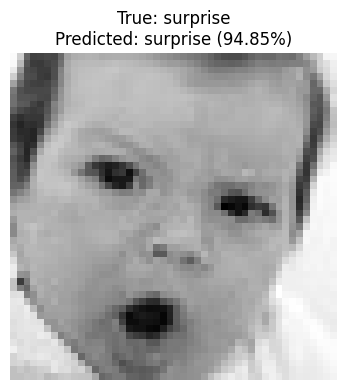

True class: surprise
Predicted class: surprise
Confidence: 94.85%


In [38]:
predicted_class, confidence, probabilities, image = predict_emotion(
    random_test_image,
    improved_model,
    class_names
)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title(
    f"True: {random_class}\nPredicted: {predicted_class} ({confidence:.2%})"
)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "single_prediction_example.png", dpi=300)
plt.show()

print("True class:", random_class)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2%}")

In [39]:
probability_df = pd.DataFrame({
    "class": class_names,
    "probability": probabilities
}).sort_values("probability", ascending=False)

probability_df

,class,probability
6,surprise,0.948469
2,fear,0.024785
0,angry,0.019098
4,neutral,0.003837
3,happy,0.001940
5,sad,0.001534
1,disgust,0.000337


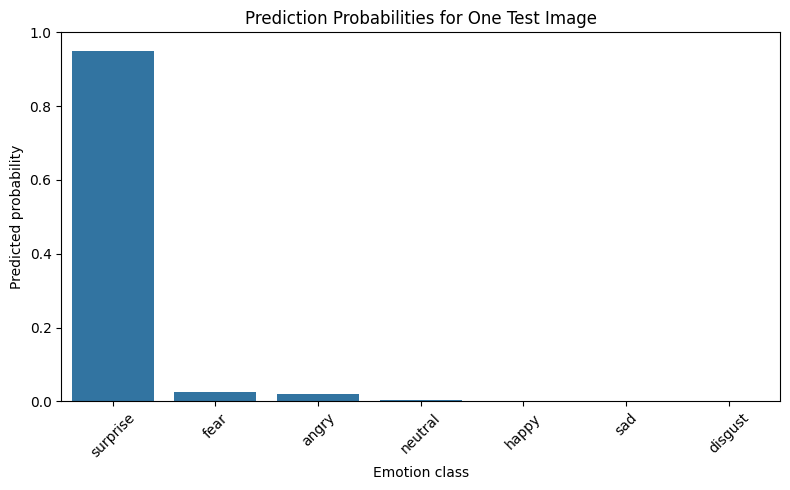

In [40]:
plt.figure(figsize=(8, 5))
sns.barplot(data=probability_df, x="class", y="probability")

plt.title("Prediction Probabilities for One Test Image")
plt.xlabel("Emotion class")
plt.ylabel("Predicted probability")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(IMAGE_DIR / "single_prediction_probabilities.png", dpi=300)
plt.show()

### Single Image Prediction Analysis

The model was tested on one image from the test dataset, which was not used during training.

The true class was **surprise**.

The model predicted **surprise** with a confidence of approximately **94.85%**.

This prediction was correct. It shows that the model can successfully apply what it learned to an unseen image.

The probability chart also shows that the model was very confident in the `surprise` class for this image. However, this is only one example, so it does not prove that the model always performs well. The full test accuracy, classification report and confusion matrix give a more reliable evaluation of the model.

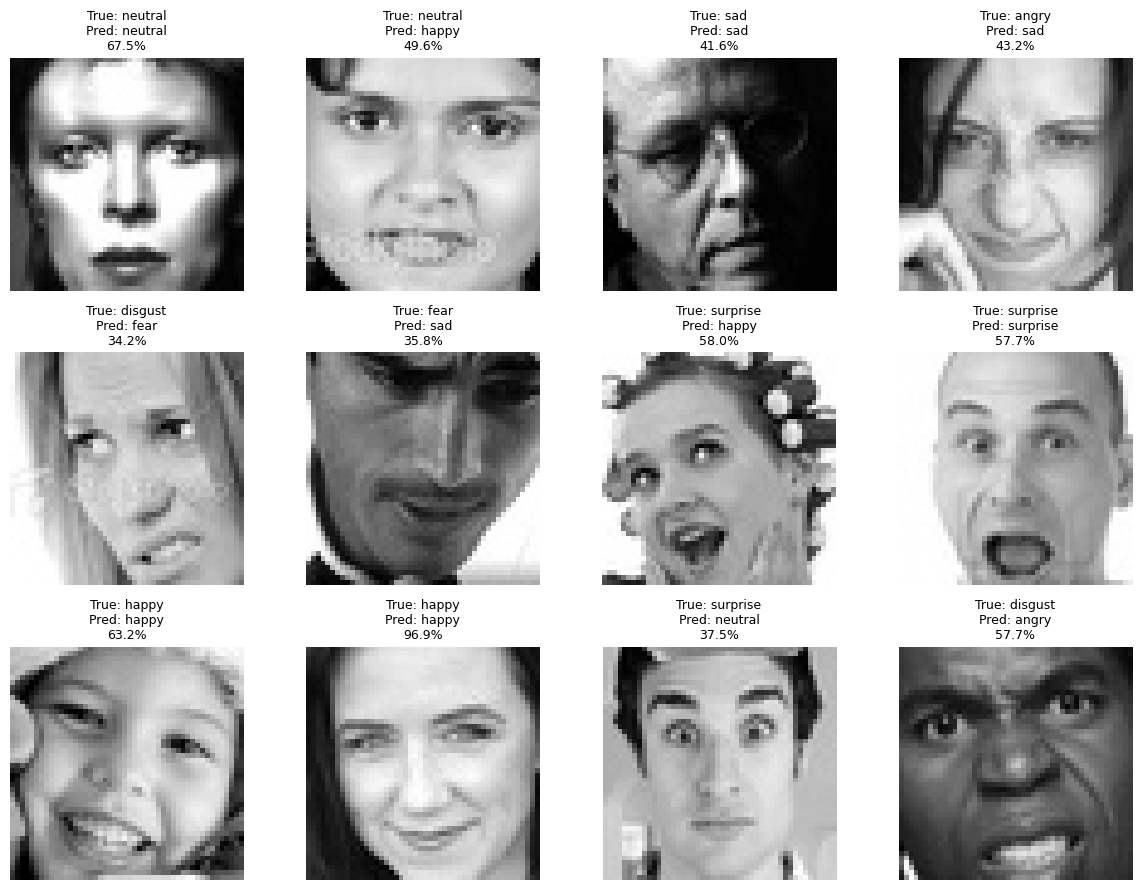

In [41]:
def show_multiple_predictions(model, class_names, num_images=12):
    selected_paths = []

    for _ in range(num_images):
        true_class = random.choice(class_names)
        image_path = random.choice(list((TEST_DIR / true_class).glob("*")))
        selected_paths.append((image_path, true_class))

    plt.figure(figsize=(12, 9))

    for i, (image_path, true_class) in enumerate(selected_paths):
        predicted_class, confidence, probabilities, image = predict_emotion(
            image_path,
            model,
            class_names
        )

        plt.subplot(3, 4, i + 1)
        plt.imshow(image, cmap="gray")
        plt.axis("off")

        title = f"True: {true_class}\nPred: {predicted_class}\n{confidence:.1%}"
        plt.title(title, fontsize=9)

    plt.tight_layout()
    plt.savefig(IMAGE_DIR / "multiple_prediction_examples.png", dpi=300)
    plt.show()


show_multiple_predictions(improved_model, class_names, num_images=12)

### Multiple Prediction Examples

The multiple prediction examples show how the model behaves on different unseen test images.

Some predictions are correct, while others may be incorrect. This is expected because the dataset is challenging and some emotions are visually similar.

These examples make the model's behavior easier to understand than accuracy alone.

In [42]:
# Summary of key model results
baseline_accuracy_percent = baseline_test_accuracy * 100
improved_accuracy_percent = improved_test_accuracy * 100
accuracy_improvement = improved_accuracy_percent - baseline_accuracy_percent

print(f"Baseline accuracy: {baseline_accuracy_percent:.2f}%")
print(f"Improved accuracy: {improved_accuracy_percent:.2f}%")
print(f"Accuracy improvement: {accuracy_improvement:.2f} percentage points")
print(f"Baseline loss: {baseline_test_loss:.4f}")
print(f"Improved loss: {improved_test_loss:.4f}")

Baseline accuracy: 55.27%
Improved accuracy: 58.40%
Accuracy improvement: 3.13 percentage points
Baseline loss: 1.2090
Improved loss: 1.0819


## 7. Final Analysis

### How well does the model work?

The improved CNN achieved a test accuracy of approximately **58.40%**, compared with the baseline CNN which achieved approximately **55.27%**.

This means that the improved model performed better than the simpler baseline model. The improvement was approximately **3.13 percentage points**, and the test loss also decreased from **1.2090** to **1.0819**.

The model has clearly learned useful visual patterns from the facial expression images. It performs much better than random guessing. Since there are seven emotion classes, random guessing would be around **14.3%**, while the improved model reaches **58.40%** on unseen test data.

However, the model is not perfect. FER-2013 is a challenging dataset because the images are small, grayscale, and sometimes visually ambiguous. Some emotions are also difficult to separate, even for humans, especially when the face image is only 48x48 pixels.

The model works best for clearer expressions such as **happy** and **surprise**. It struggles more with classes such as **disgust**, **fear** and **sad**.

### Do I see signs of overfitting or underfitting?

To analyze overfitting and underfitting, I compared the training and validation curves.

The improved model used **dropout**, **batch normalization** and **data augmentation** to reduce the risk of overfitting. These techniques helped the model generalize better than the baseline CNN.

The improved model did not train for all 25 epochs. EarlyStopping stopped the training after validation performance stopped improving. This is a good sign because it prevents the model from continuing to train after it has reached its best validation performance.

There may still be some overfitting if the training accuracy is higher than the validation accuracy. This is common in image classification tasks, especially when the dataset is noisy or imbalanced.

I do not see strong underfitting because the model is clearly able to learn meaningful patterns. If the model was underfitting, both training and validation accuracy would remain very low. Instead, the model reaches much better performance than random guessing and improves compared with the baseline model.

Overall, the improved model shows better generalization than the baseline, but there is still room for improvement.

### How do the results differ between training data, validation data and test data?

The training data is used by the model to learn patterns. The validation data is used during training to check whether the model is improving on unseen data. The test data is used only after training to evaluate the final model.

The baseline CNN achieved approximately **55.27%** test accuracy. The improved CNN achieved approximately **58.40%** test accuracy. This shows that the improvements were useful not only during training, but also on unseen test images.

If the training accuracy is much higher than validation or test accuracy, it means the model has learned the training data better than it generalizes to new data. This is a sign of overfitting.

In this project, the improved model performs reasonably on test data, but the result also shows that facial expression recognition is difficult. The model can generalize to new images, but it still makes mistakes, especially for visually similar or underrepresented emotion classes.

### What seems to affect the result most?

Several factors affected the model result.

First, **class imbalance** had a large effect. The dataset contains many more images for some classes than others. For example, the `happy` class has many training images, while the `disgust` class has very few. This makes it easier for the model to learn `happy` and harder to learn `disgust`.

Second, **image quality and image size** affected the result. The images are only 48x48 pixels and grayscale. This means that many facial details are missing compared with larger color images.

Third, **some emotions are visually similar**. For example, `sad` and `neutral` can look similar. `fear` and `surprise` can also share features such as wide eyes or an open mouth. This makes classification difficult.

Fourth, **model architecture** affected performance. The improved model performed better than the baseline model. This shows that more convolutional layers, dropout, batch normalization and data augmentation helped improve the result.

Finally, **data quality** is important. If some images are unclear or if some labels are subjective, the model will also struggle. Deep learning models learn from the data they are given, so dataset quality has a direct effect on model quality.

### Per-class performance

The classification report and confusion matrix show that the model does not perform equally well on all emotion classes.

The strongest classes are **happy**, **surprise** and **neutral**.

The `happy` class performs best, with an F1-score of approximately **0.82**. This is probably because happy expressions are visually clearer and because the dataset contains many happy images.

The weakest classes are **disgust**, **fear** and **sad**.

The `disgust` class performs worst, with an F1-score of approximately **0.08** and recall of only approximately **0.05**. This means that the model almost never detects real disgust images. One likely reason is that the disgust class has far fewer training examples than the other classes.

The `fear` class is also difficult for the model, with an F1-score of approximately **0.31**. Fear can look similar to surprise or sad expressions in small grayscale images.

The `neutral` class has higher recall than precision. This suggests that the model sometimes predicts neutral when it is uncertain.

This shows why overall accuracy is not enough. A model can have acceptable total accuracy while still performing poorly on specific classes. For a deeper evaluation, precision, recall, F1-score and the confusion matrix are necessary.

### Limitations of the model

The model has several limitations.

- It is trained only on 48x48 grayscale images, so it may not perform well on normal high-resolution color photos without careful preprocessing.
- The dataset is imbalanced, especially for the `disgust` class.
- Some facial expressions are subjective and can be difficult even for humans to label correctly.
- The model only predicts one of seven fixed emotion classes and cannot understand complex emotional states.
- The model has not been tested enough on real-world camera images with different lighting, angles, backgrounds and face positions.
- The model may reflect limitations or bias from the dataset it was trained on.

Because of these limitations, this type of model should be used carefully. It is useful for learning, experimentation and portfolio demonstration, but it should not be used alone for important decisions about people.

### When is deep learning a good choice?

Deep learning is a good choice when the problem involves complex patterns, such as images, sound or natural language.

In this project, a CNN is suitable because facial expression classification depends on visual patterns in images. A traditional rule-based program would be very difficult to write for this task because it is hard to manually define rules for every possible mouth shape, eye position, eyebrow movement and facial expression.

CNNs are useful because they can learn image features directly from pixel data. Early layers can learn simple features such as edges and shadows, while deeper layers can learn more complex patterns related to facial expressions.

However, deep learning is not always the best choice. It usually needs a lot of data, training time and careful evaluation. For smaller or simpler problems, traditional machine learning or rule-based methods may be enough.

For this project, deep learning is a good choice because the task is image classification and the important patterns are visual.

## 8. Reflection

### What was the most difficult part?

The most difficult part was understanding how all parts of the deep learning workflow connect together.

At the beginning, it is easy to think that the task is only about building a model and training it. But this project showed me that the full workflow is much bigger. I needed to understand the dataset, prepare the images correctly, build a model, train it, evaluate it, compare different model versions and interpret the result.

Another difficult part was understanding overfitting. A model can become better on training data but still perform worse on unseen data. This helped me understand why validation data, test data, dropout, data augmentation and EarlyStopping are important.

### What did I learn?

I learned how to build and train CNN models for image classification.

I learned what convolutional layers, pooling layers, dense layers, dropout, batch normalization and data augmentation do in a deep learning model.

I also learned that accuracy alone is not enough to evaluate a model. The classification report and confusion matrix gave a much deeper understanding of which emotion classes the model handled well and which ones were difficult.

The project also showed me how important the dataset is. The model struggled with the `disgust` class because it had much fewer images than the other classes. This showed me that model performance depends not only on architecture, but also on data balance and data quality.

### What would I do differently if I started again?

If I started again, I would spend more time experimenting with class imbalance.

For example, I could try:

- class weights
- oversampling of smaller classes
- stronger augmentation for underrepresented classes
- comparing more CNN architectures

I would also test the model on more real-world images outside the dataset. This would help me understand how well the model works outside the controlled FER-2013 test set.

Another improvement would be to experiment with transfer learning or pretrained models, although this would need extra care because FER-2013 images are grayscale and very small.

### Which grade do I think the submission corresponds to?

I think this submission corresponds to **VG**.

The project fulfills the requirements for G because it includes:

- a working CNN model
- correct training and validation
- evaluation on test data
- prediction on unseen images
- analysis of the result
- discussion of overfitting and limitations

The project also fulfills several VG requirements because I compared multiple model variants. I trained a baseline CNN and an improved CNN, then compared their test accuracy and test loss.

I also improved the model by adding more convolutional layers, dropout, batch normalization, data augmentation and EarlyStopping. I analyzed the training curves, compared model performance, used a classification report and confusion matrix, and discussed why the model performs differently for different emotion classes.

The project includes a saved model and will also be extended with a Streamlit dashboard. This makes the project stronger as a portfolio project, not only as a school assignment.